In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [207]:
import importlib

datasets = {
  "power": "power/data.npy",
  "gas": "gas/ethylene_CO.csv",
  "hepmass": "hepmass",
  "miniboone": "miniboone/data.npy",
}
dataset = "power"

# (1659917, 6)
# (852174, 8)
# (315123, 21)
# (29556, 43)

if dataset not in datasets:
  raise ValueError(f"Dataset {dataset} not in {datasets}")

# Dynamically import module
module = importlib.import_module(f"uci.{dataset}")

# Dynamically get class
cls = getattr(module, dataset.upper())

# Instantiate
data = cls(f"uci/data/{datasets[dataset]}")

In [208]:
x_trn = data.trn.x
x_val = data.val.x
x_tst = data.tst.x

In [209]:
print(pd.DataFrame(x_trn).describe())
print(pd.DataFrame(x_tst).describe())

               0          1          2          3          4          5
count  1.660e+06  1.660e+06  1.660e+06  1.660e+06  1.660e+06  1.660e+06
mean  -3.915e-04  8.359e-05 -2.693e-04 -1.852e-04 -1.138e-04 -1.973e-04
std    9.996e-01  9.999e-01  9.992e-01  9.998e-01  1.000e+00  1.000e+00
min   -9.608e-01 -5.446e+00 -2.633e-01 -3.085e-01 -8.240e-01 -1.732e+00
25%   -7.407e-01 -5.714e-01 -2.190e-01 -2.474e-01 -7.528e-01 -8.670e-01
50%   -4.642e-01  5.227e-02 -1.747e-01 -1.862e-01 -6.623e-01  3.214e-04
75%    4.130e-01  6.317e-01 -1.305e-01 -9.164e-02  1.298e+00  8.664e-01
max    9.490e+00  4.108e+00  1.419e+01  1.355e+01  2.966e+00  1.731e+00
                0          1           2          3           4           5
count  204928.000  2.049e+05  204928.000  2.049e+05  204928.000  204928.000
mean        0.004  2.175e-04       0.003 -5.027e-04       0.003       0.003
std         1.003  1.001e+00       1.010  9.988e-01       1.001       1.000
min        -0.959 -5.070e+00      -0.263 -3.085e

In [239]:
class Uniform:
  def __init__(self, xmin=0, xmax=1, type="continuous"):
    if type != "continuous":
      raise ValueError("Uniform distribution only supports continuous type.")
    self.xmin = xmin
    self.xmax = xmax
    self.type = type

  def fit(self, x):
    pass

  def cdf(self, x):
    return np.clip((x - self.xmin) / (self.xmax - self.xmin), 0, 1)

  def pdf(self, u):
    return np.where(
      (u >= self.xmin) & (u <= self.xmax), 1 / (self.xmax - self.xmin), 0
    )


# margins_controls = {
#   0: {"kde": {"xmin": 0, "type": "continuous"}},
#   1: {"kde": {"type": "continuous"}},
#   2: {"kde": {"xmin": 0, "xmax": 88, "type": "discrete"}},
#   3: {"kde": {"xmin": 0, "xmax": 80, "type": "discrete"}},
#   4: {"kde": {"xmin": 0, "xmax": 31, "type": "discrete"}},
#   # 5: {"uniform": {"xmin": 0, "xmax": 1440, "type": "continuous"}},
# }


# d = x_trn.shape[1]
# margins = [
#   Uniform(**margins_controls[i]["uniform"])
#   if "uniform" in margins_controls[i]
#   else pv.Kde1d(**margins_controls[i]["kde"], degree=0)
#   for i in range(d)
# ]
# for i in range(d):
#   margins[i].fit(x_trn[:, i])

# margins_loglik = np.column_stack(
#   [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
# )
# margins_loglik.mean(axis=0)

In [278]:
margins_controls = {
  0: {"kde": {"type": "continuous", "degree": 0}},
  1: {"kde": {"type": "continuous", "degree": 2}},
  2: {"kde": {"type": "continuous", "degree": 0}},
  3: {"kde": {"type": "continuous", "degree": 0}},
  4: {"kde": {"type": "continuous", "degree": 0}},
  5: {"kde": {"type": "continuous", "degree": 0}},
  # 5: {
  #   "uniform": {
  #     "xmin": x_trn[:, 5].min(),
  #     "xmax": x_trn[:, 5].max(),
  #     "type": "continuous",
  #   }
  # },
}

d = x_trn.shape[1]
margins = [
  pv.Kde1d(**margins_controls[i]["kde"])
  if "kde" in margins_controls[i]
  else Uniform(**margins_controls[i]["uniform"])
  for i in range(d)
]
for i in range(d):
  margins[i].fit(x_trn[:, i])

margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
)
margins_loglik.mean(axis=0)

array([-0.7364886 , -1.40302533,  1.31664319,  0.72026187,  0.48198136,
       -1.24634922])

In [ ]:
u_trn = np.column_stack([margins[i].cdf(x_trn[:, i]) for i in range(d)])
u_val = np.column_stack([margins[i].cdf(x_val[:, i]) for i in range(d)])
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])

In [280]:
# for i in range(d):
#   plt.figure(figsize=(8, 4))
#   plt.title(f"Variable {i}")
#   plt.hist(
#     x_trn[:, i], bins=100, density=True, alpha=0.5, label="Training data"
#   )
#   plt.hist(
#     x_val[:, i], bins=100, density=True, alpha=0.5, label="Validation data"
#   )
#   x = np.linspace(
#     margins[i].grid_points.min(), margins[i].grid_points.max(), 1000
#   )
#   plt.plot(x, margins[i].pdf(x), label="KDE PDF", color="red")
#   plt.xlabel(f"Variable {i}")
#   plt.ylabel("Density")
#   plt.legend()
#   plt.show()

In [259]:
# i = 0
# multiplier = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# val_loglik = []
# for m in multiplier:
#   margins = [
#     pv.Kde1d(**margins_controls[i]["kde"], degree=0, multiplier=m)
#     for i in range(d)
#   ]
#   for i in range(d):
#     margins[i].fit(x_trn[:, i])

#   margins_loglik = np.column_stack(
#     [np.log(margins[i].pdf(x_val[:, i])) for i in range(d)]
#   )
#   val_loglik.append(margins_loglik.mean(axis=0))

# val_loglik = np.array(val_loglik)

# plt.figure(figsize=(10, 6))
# plt.plot(multiplier, val_loglik[:, 0], label="x1")
# plt.plot(multiplier, val_loglik[:, 1], label="x2")
# plt.plot(multiplier, val_loglik[:, 2], label="x3")
# plt.plot(multiplier, val_loglik[:, 3], label="x4")
# plt.plot(multiplier, val_loglik[:, 4], label="x5")
# plt.plot(multiplier, val_loglik[:, 5], label="x6")
# plt.xscale("log")
# plt.xlabel("Multiplier")
# plt.ylabel("Log-likelihood")
# plt.title("Validation log-likelihood for different multipliers")
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
import math


def grid_size_per_axis(n: int, h: float | None = None, c: float = 0.7) -> int:
  """
  Compute the number of grid points per axis for a 2D KDE table
  with bilinear interpolation.

  Parameters
  ----------
  n : int
      Sample size.
  h : float or None, optional
      Bandwidth. If None, uses rule-of-thumb h ~ n^(-1/6).
  c : float, optional
      Safety constant (< 1). Default 0.7.

  Returns
  -------
  m : int
      Grid size per axis.
  """
  if h is None:
    # rule-of-thumb bandwidth for 2D
    h = n ** (-1 / 6)

  # grid spacing Δ = c * h * (n h^2)^(-1/4)
  delta = c * h * (n * h**2) ** (-0.25)

  # number of intervals on [0,1]
  m = math.ceil(1.0 / delta)
  return m

In [ ]:
sample_size = 200000
nonparametric_grid_size = 1000
u_trn_sub = u_trn[
  np.random.choice(u_trn.shape[0], sample_size, replace=False), :
]
cop = pv.Vinecop.from_data(
  u_trn_sub,
  controls=pv.FitControlsVinecop(
    family_set=[pv.tll],
    nonparametric_grid_size=nonparametric_grid_size,
    num_threads=1,
  ),
)

In [323]:
from vinesforest import VinesForest

controls = pv.FitControlsVinecop(
  family_set=[pv.tll], num_threads=1, nonparametric_grid_size=10
)

# Create an instance of VinesForest
forest = VinesForest(controls=controls)

# Subsampled data for training
u_trn_sub = u_trn[np.random.choice(u_trn.shape[0], 10000, replace=False), :]
u_val_sub = u_val[np.random.choice(u_val.shape[0], 10000, replace=False), :]
forest.fit(u_trn_sub, u_val_sub)

In [349]:
n = 400000
best_vine = forest.logliks_forest.mean(axis=1).argmax()
u_trn_sub = u_trn[np.random.choice(u_trn.shape[0], n, replace=False), :]
cop2 = forest.vines[best_vine]
m = grid_size_per_axis(n, h=None, c=0.7)
cop2.fit(
  u_trn_sub,
  controls=pv.FitControlsBicop(family_set=[pv.tll], nonparametric_grid_size=m),
)
np.log(cop2.pdf(u_tst)).mean()

np.float64(0.9865773291374371)

In [350]:
u_tst = np.column_stack([margins[i].cdf(x_tst[:, i]) for i in range(d)])
margins_loglik = np.column_stack(
  [np.log(margins[i].pdf(x_tst[:, i])) for i in range(d)]
)
cop_loglik = np.log(cop.pdf(u_tst)).mean()
print(
  cop_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop_loglik,
)

cop2_loglik = np.log(cop2.pdf(u_tst)).mean()
print(
  cop2_loglik,
  margins_loglik.mean(axis=0).sum(),
  margins_loglik.mean(axis=0).sum() + cop2_loglik,
)

0.935617196034843 -0.8773928531519191 0.058224342882923885
0.9865773291374371 -0.8773928531519191 0.10918447598551806


<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 0')

(array([1.91529174, 1.74712059, 1.49998084, 1.201359  , 1.32218206,
        1.19781294, 1.17067552, 1.03353694, 1.0942057 , 0.96682335,
        0.88724843, 0.84864605, 0.85535232, 0.84690058, 0.85816344,
        0.75564022, 0.9108398 , 0.81281804, 0.87684912, 0.87510366,
        0.83295522, 0.81377346, 0.84276658, 0.85496648, 0.85052013,
        0.84627589, 0.85555443, 0.85072224, 0.85180627, 0.84579818]),
 array([0.0039237 , 0.03712237, 0.07032104, 0.10351971, 0.13671838,
        0.16991704, 0.20311571, 0.23631438, 0.26951305, 0.30271172,
        0.33591039, 0.36910906, 0.40230773, 0.4355064 , 0.46870507,
        0.50190374, 0.53510241, 0.56830108, 0.60149975, 0.63469841,
        0.66789708, 0.70109575, 0.73429442, 0.76749309, 0.80069176,
        0.83389043, 0.8670891 , 0.90028777, 0.93348644, 0.96668511,
        0.99988378]),
 <BarContainer object of 30 artists>)

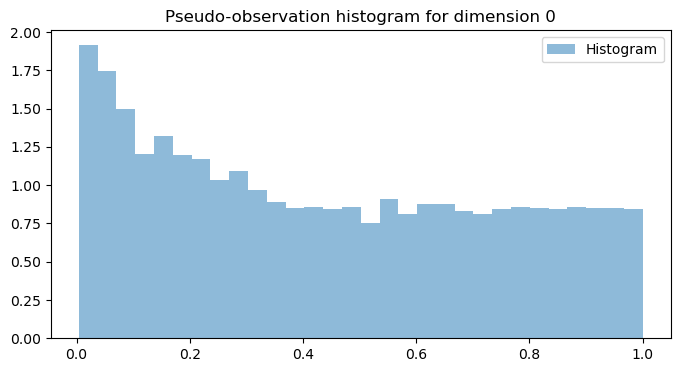

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 1')

(array([1.00159413, 1.00183232, 0.99983518, 0.99213977, 1.0100774 ,
        0.99093049, 0.99785636, 0.99897403, 1.01509774, 1.01504277,
        1.0044341 , 0.99087552, 1.01458471, 0.99475987, 0.97748185,
        1.03147797, 0.98970289, 1.01810261, 0.97903925, 1.00349966,
        0.99322079, 1.02506513, 0.97390898, 1.00390275, 0.99943209,
        1.01832248, 0.99913893, 0.99067398, 1.00109942, 1.00608312]),
 array([1.56063142e-04, 3.34470212e-02, 6.67379793e-02, 1.00028937e-01,
        1.33319895e-01, 1.66610854e-01, 1.99901812e-01, 2.33192770e-01,
        2.66483728e-01, 2.99774686e-01, 3.33065644e-01, 3.66356602e-01,
        3.99647560e-01, 4.32938518e-01, 4.66229476e-01, 4.99520434e-01,
        5.32811392e-01, 5.66102350e-01, 5.99393309e-01, 6.32684267e-01,
        6.65975225e-01, 6.99266183e-01, 7.32557141e-01, 7.65848099e-01,
        7.99139057e-01, 8.32430015e-01, 8.65720973e-01, 8.99011931e-01,
        9.32302889e-01, 9.65593847e-01, 9.98884805e-01]),
 <BarContainer object of 30 

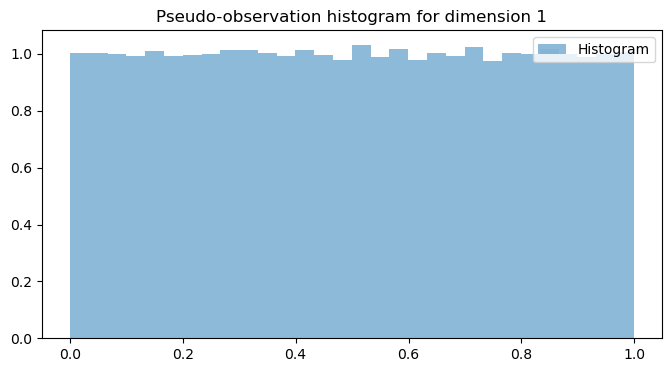

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 2')

(array([27.68365708,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.25448784,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.28054204,  0.        ,  0.05518075,  0.09169797,
         0.09040956,  0.02825299,  0.07735981,  0.        ,  0.21838547,
         0.        ,  0.23855828,  0.        ,  0.09455088,  0.0619173 ]),
 array([0.        , 0.03314002, 0.06628003, 0.09942005, 0.13256007,
        0.16570008, 0.1988401 , 0.23198012, 0.26512013, 0.29826015,
        0.33140017, 0.36454018, 0.3976802 , 0.43082022, 0.46396023,
        0.49710025, 0.53024027, 0.56338028, 0.5965203 , 0.62966032,
        0.66280033, 0.69594035, 0.72908037, 0.76222038, 0.7953604 ,
        0.82850042, 0.86164043, 0.89478045, 0.92792047, 0.96106048,
        0.9942005 ]),
 <BarContainer object of 30 artists>)

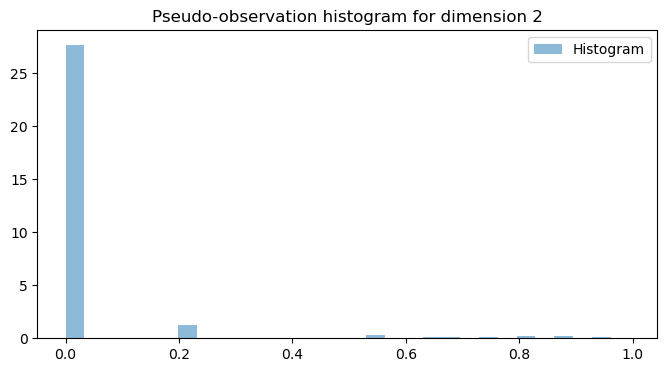

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 3')

(array([21.03420471,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  8.96579531]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

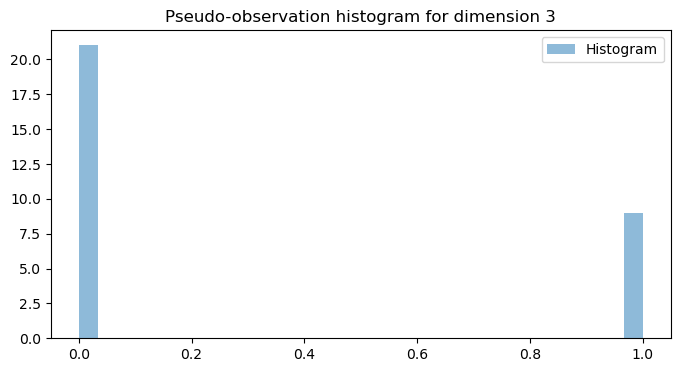

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 4')

(array([92.0416621 ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , 50.97220069,
         0.        ,  0.        ,  0.        ,  0.20934112,  0.        ,
         0.20866626,  0.20650671,  0.        ,  0.20677666,  0.21271541,
         0.42313631,  0.2185192 ,  1.57754933,  1.8024122 ,  0.63288234,
        18.68818276, 51.16912441,  0.65852697,  0.31407917,  1.73357662]),
 array([0.        , 0.00451925, 0.00903849, 0.01355774, 0.01807698,
        0.02259623, 0.02711547, 0.03163472, 0.03615397, 0.04067321,
        0.04519246, 0.0497117 , 0.05423095, 0.0587502 , 0.06326944,
        0.06778869, 0.07230793, 0.07682718, 0.08134642, 0.08586567,
        0.09038492, 0.09490416, 0.09942341, 0.10394265, 0.1084619 ,
        0.11298115, 0.11750039, 0.12201964, 0.12653888, 0.13105813,
        0.13557737]),
 <BarContainer object of 30 artists>)

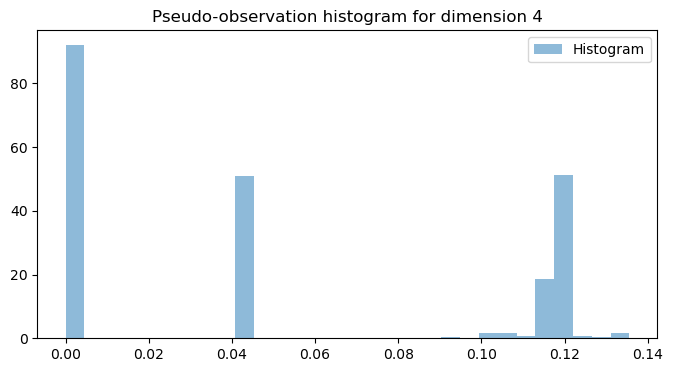

<Figure size 800x400 with 0 Axes>

Text(0.5, 1.0, 'Pseudo-observation histogram for dimension 5')

(array([1.00471264, 0.99913141, 1.00215077, 0.99929611, 0.99865564,
        0.99953399, 0.99882033, 1.00077833, 0.99874713, 1.00050385,
        1.00167499, 0.99887523, 0.99561798, 1.00044895, 0.99988168,
        0.99863734, 1.00196778, 1.00253505, 0.99753939, 0.99790537,
        0.99828965, 1.00090643, 0.99993657, 0.99880203, 1.00255335,
        0.99891182, 1.00024766, 0.9993327 , 0.99865564, 1.00495053]),
 array([3.52466751e-09, 3.33333365e-02, 6.66666695e-02, 1.00000002e-01,
        1.33333335e-01, 1.66666668e-01, 2.00000001e-01, 2.33333334e-01,
        2.66666667e-01, 3.00000000e-01, 3.33333333e-01, 3.66666666e-01,
        3.99999999e-01, 4.33333332e-01, 4.66666665e-01, 4.99999998e-01,
        5.33333331e-01, 5.66666664e-01, 5.99999997e-01, 6.33333330e-01,
        6.66666663e-01, 6.99999996e-01, 7.33333329e-01, 7.66666662e-01,
        7.99999995e-01, 8.33333328e-01, 8.66666661e-01, 8.99999994e-01,
        9.33333327e-01, 9.66666660e-01, 9.99999993e-01]),
 <BarContainer object of 30 

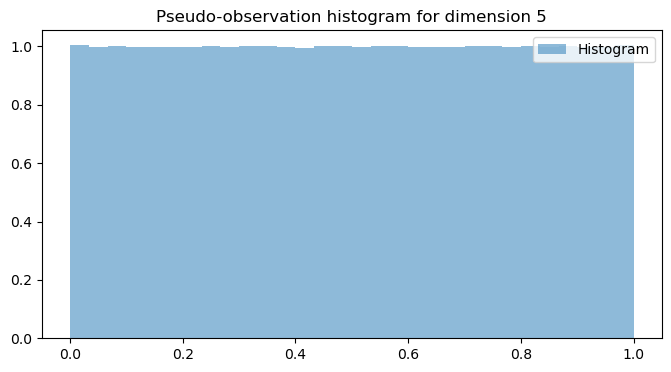

In [ ]:
for i, model in enumerate(margins):
  plt.figure(figsize=(8, 4))
  plt.title(f"Pseudo-observation histogram for dimension {i}")
  plt.hist(u_trn[:, i], bins=30, density=True, alpha=0.5, label="Histogram")
  plt.legend()
  plt.show()